<a href="https://colab.research.google.com/github/hana-cmd/2024_Yohana-Butar-Butar_Responsi/blob/main/Update_Capstone_Project_Klasifikasi_Data_Sampah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# About Dataset

Dataset ini merupakan dataset yang didapat dari Hugging Face. Merupakan dataset yang akan digunakan untuk melakukan klasifikasi sampah untuk memudahkan dalam proses pemilahan sampah.

# Data Loading

In [4]:
# mengekstrak dataset
!unzip -q /content/dataset-resized.zip -d/content/raw_dataset

print("Ektraksi di Session Storage Selesai!")

Ektraksi di Session Storage Selesai!


## 1. Pengelompokkan dan Pelabelan Dataset

In [5]:
import os
import shutil

# 1.  Menentukan lokasi asal dan lokasi tujuan baru di session storage
src_base ="/content/raw_dataset/dataset-resized"
target_base = "/content/dataset_sampah"

# 2. Definisikan pemetaan kategori sampah
mapping = {
    'Organik' : ['cardboard','paper'],
    'Anorganik' : ['glass','metal','plastic'],
    'Lainnya' : ['trash']
}

# 3. Membuat folder dan menyalin file
for main_category, sub_folders in mapping.items():
    dest_dir = os.path.join(target_base, main_category)
    os.makedirs(dest_dir, exist_ok=True)

    for sub in sub_folders:
        source_dir = os.path.join(src_base, sub)
        if os.path.exists(source_dir):
            for file_name in os.listdir(source_dir):
                full_file_name = os.path.join(source_dir, file_name)
                if os.path.isfile(full_file_name):
                    shutil.copy(full_file_name, dest_dir)

print("Pengelompokan selesai! Folder '/content/dataset_sampah' selanjutnya akan dilakukan Exploratory Data Analysis.")

Pengelompokan selesai! Folder '/content/dataset_sampah' selanjutnya akan dilakukan Exploratory Data Analysis.


# Exploratory Data Analysis

## Analisis Distribusi Kelas

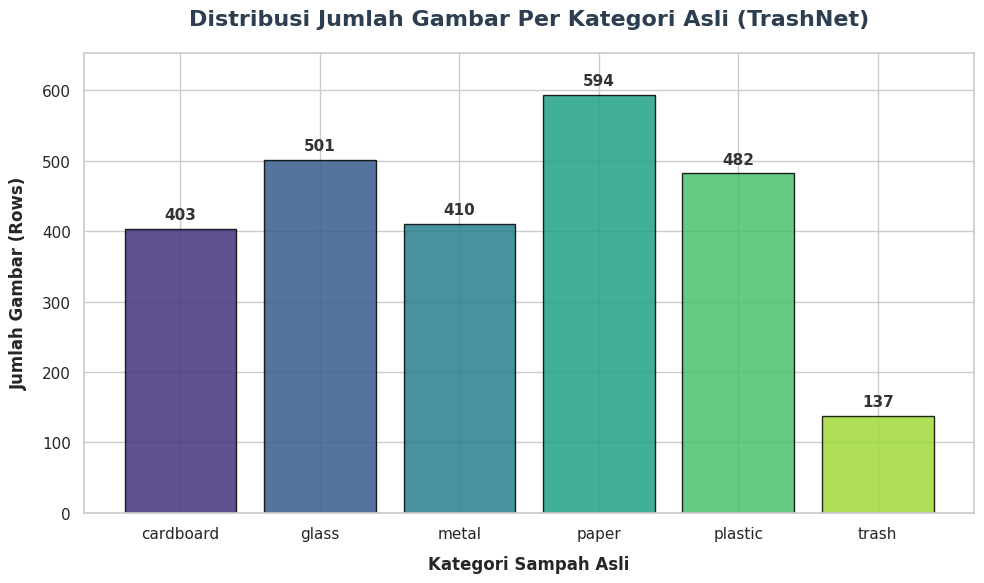

In [6]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Path ke folder hasil ekstraksi asli TrashNet
raw_data_dir = "/content/raw_dataset/dataset-resized"

# 2. Ambil nama folder dan hitung jumlah file di dalamnya
sub_folders = []
counts = []

for sub in sorted(os.listdir(raw_data_dir)):
    sub_path = os.path.join(raw_data_dir, sub)
    if os.path.isdir(sub_path):
        sub_folders.append(sub)
        counts.append(len(os.listdir(sub_path)))

# 3. Pengaturan tema grafik agar terlihat modern dan bersih
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 4. Membuat Bar Plot dengan palet warna yang menarik
colors = sns.color_palette("viridis", len(sub_folders))
bars = plt.bar(sub_folders, counts, color=colors, edgecolor='black', alpha=0.85)

# 5. MENAMBAHKAN LABEL ANGKA di atas setiap batang (Bar)
plt.gca().bar_label(bars, padding=5, fontsize=11, weight='bold', color='#333333')

# 6. Menghias Grafik (Judul, Label, dll)
plt.title('Distribusi Jumlah Gambar Per Kategori Asli (TrashNet)', fontsize=16, pad=20, weight='bold', color='#2c3e50')
plt.xlabel('Kategori Sampah Asli', fontsize=12, labelpad=10, weight='bold')
plt.ylabel('Jumlah Gambar (Rows)', fontsize=12, labelpad=10, weight='bold')

# Memberikan sedikit ruang tambahan di atas grafik agar label angka tidak terpotong
plt.ylim(0, max(counts) * 1.1)

# Menampilkan grafik
plt.tight_layout()
plt.show()

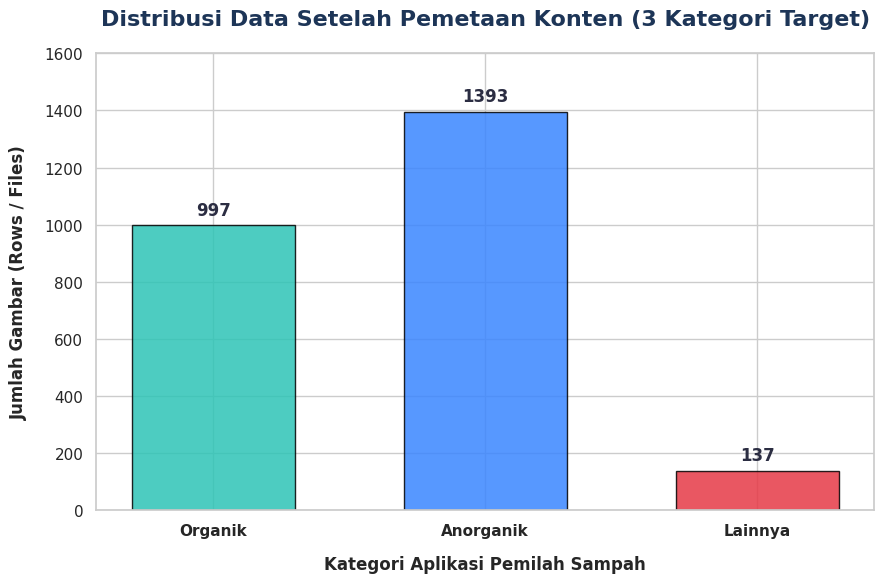

In [7]:
# 1. Path ke folder dataset yang sudah dikelompokkan
target_base = "/content/dataset_sampah"
categories = ['Organik', 'Anorganik', 'Lainnya']

# 2. Hitung jumlah gambar di masing-masing kategori baru
counts = []
for cat in categories:
    cat_path = os.path.join(target_base, cat)
    if os.path.exists(cat_path):
        counts.append(len(os.listdir(cat_path)))
    else:
        counts.append(0)

# 3. Set tema agar visualisasi terlihat modern dan profesional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# 4. Gunakan palet warna yang representatif untuk jenis sampah
# Hijau untuk Organik, Biru untuk Anorganik, Merah/Oranye untuk Lainnya
custom_colors = ['#2ec4b6', '#3a86ff', '#e63946']

bars = plt.bar(categories, counts, color=custom_colors, edgecolor='black', alpha=0.85, width=0.6)

# 5. MENAMBAHKAN LABEL ANGKA di atas setiap batang grafik
plt.gca().bar_label(bars, padding=5, fontsize=12, weight='bold', color='#2b2d42')

# 6. Menghias Grafik (Judul, Axis Label, Gaya Huruf)
plt.title('Distribusi Data Setelah Pemetaan Konten (3 Kategori Target)', fontsize=16, pad=20, weight='bold', color='#1d3557')
plt.xlabel('Kategori Aplikasi Pemilah Sampah', fontsize=12, labelpad=12, weight='bold')
plt.ylabel('Jumlah Gambar (Rows / Files)', fontsize=12, labelpad=12, weight='bold')

# Memberikan ruang aman di bagian atas grafik agar angka tidak menempel di bingkai
plt.ylim(0, max(counts) * 1.15)

# Mengubah label sumbu X menjadi huruf kapital di awal agar lebih rapi
plt.xticks(range(len(categories)), [cat.capitalize() for cat in categories], fontsize=11, weight='bold')

# Tampilkan plot
plt.tight_layout()
plt.show()

## Visualisasi Gambar Sampel

Found 2527 files belonging to 3 classes.
Using 2022 files for training.


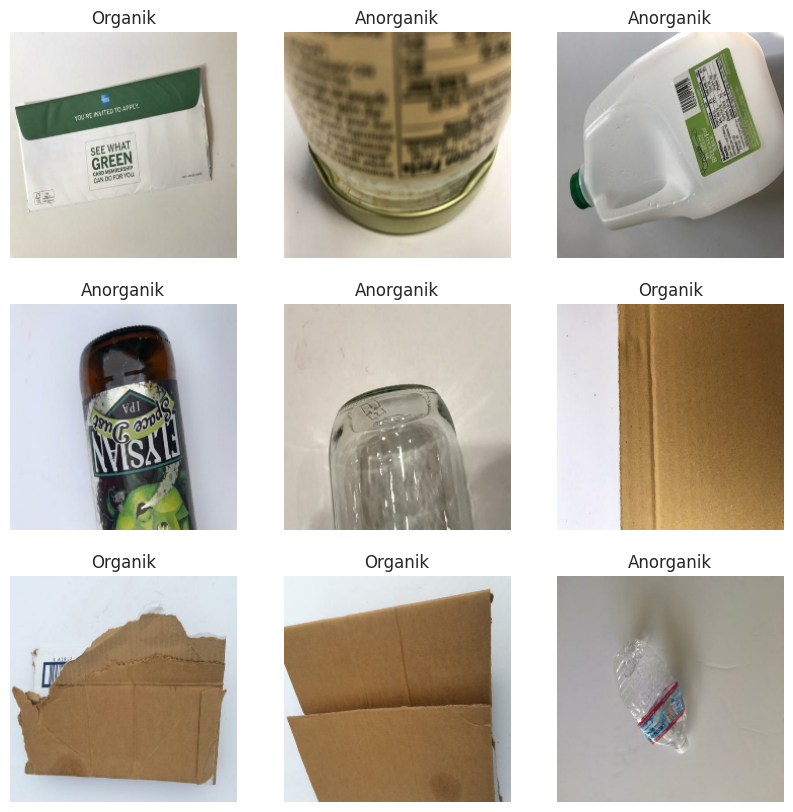

In [8]:
import tensorflow as tf

data_dir = "/content/dataset_sampah"

# Muat data training dengan ukuran standar 224x224
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,   # 20% langsung dicadangkan untuk validasi nanti
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names

# Menampilkan 9 gambar pertama dari dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

# Data Preprocessing

## Splitting Dataset

In [9]:
import tensorflow as tf

data_dir = "/content/dataset_sampah"
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

# 1. Muat seluruh data mentah dari folder (100%)
raw_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True # Di-shuffle acak dulu agar pembagian kelasnya merata
)

# Hitung total batch yang ada
total_batches = len(raw_ds)
print(f"Total batches yang tersedia: {total_batches}")

# 2. Tentukan porsi pembagian batch (80% Train, 10% Val, 10% Test)
train_size = int(0.8 * total_batches)
val_size = int(0.1 * total_batches)
test_size = total_batches - (train_size + val_size)

# 3. Potong dataset secara presisi
train_ds = raw_ds.take(train_size)                  # Ambil 80% pertama
remaining_ds = raw_ds.skip(train_size)             # Lewati 80% yang sudah diambil
val_ds = remaining_ds.take(val_size)               # Ambil 10% berikutnya untuk Val
test_ds = remaining_ds.skip(val_size)              # Sisanya (10%) resmi jadi Test Dataset

print("\n=== HASIL AKHIR SPLITTING ===")
print(f"Jumlah batch Data Training   : {len(train_ds)} batch (~{len(train_ds)*BATCH_SIZE} gambar)")
print(f"Jumlah batch Data Validasi   : {len(val_ds)} batch (~{len(val_ds)*BATCH_SIZE} gambar)")
print(f"Jumlah batch Data Testing    : {len(test_ds)} batch (~{len(test_ds)*BATCH_SIZE} gambar)")

Found 2527 files belonging to 3 classes.
Total batches yang tersedia: 79

=== HASIL AKHIR SPLITTING ===
Jumlah batch Data Training   : 63 batch (~2016 gambar)
Jumlah batch Data Validasi   : 7 batch (~224 gambar)
Jumlah batch Data Testing    : 9 batch (~288 gambar)


## Normalisasi Data

In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Mengubah piksel 0-255 menjadi 0.0-1.0 khusus data training
normalized_train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

# Verifikasi rentang nilai piksel training
image_batch, labels_batch = next(iter(normalized_train_ds))
print("Rentang piksel setelah normalisasi training:")
print("Min:", image_batch[0].numpy().min(), " | Max:", image_batch[0].numpy().max())

Rentang piksel setelah normalisasi training:
Min: 0.14649862  | Max: 1.0


In [11]:
# Terapkan normalisasi skala piksel tanpa augmentasi agar data validasi & uji tetap objektif
normalized_val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
normalized_test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

print("Langkah 8 Selesai: Data validasi dan testing berhasil dinormalisasi!")

Langkah 8 Selesai: Data validasi dan testing berhasil dinormalisasi!


In [12]:
# 1. Membuat pipeline augmentasi gambar acak untuk memperkaya data training
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

# 2. Terapkan augmentasi hanya pada data training yang telah dinormalisasi
augmented_train_ds = normalized_train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# 3. Masukkan konfigurasi prefetch dan cache agar proses komputasi memori efisien
AUTOTUNE = tf.data.AUTOTUNE
final_train_ds = augmented_train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
final_val_ds = normalized_val_ds.cache().prefetch(buffer_size=AUTOTUNE)
final_test_ds = normalized_test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("=== PIPELINE PREPROCESSING SELESAI ===")

=== PIPELINE PREPROCESSING SELESAI ===


# Development & AI Ineregation
Tujuan utama penelitian ini adalah mengembangkan model klasifikasi citra untuk mengelompokkan sampah ke dalam kategori 'organik', 'anorganik', dan 'lainnya'. Model dibangun menggunakan deep learning serta dievaluasi agar dapat diintegrasikan ke dalam pemilahan sampah.


Definisikan arsitektur Convolutional Neural Network (CNN) kustom dari awal menggunakan `tf.keras.layers`. Arsitektur ini akan mencakup lapisan Konvolusi, Max Pooling, Flatten, dan Dense untuk klasifikasi gambar.


###Optimasi Model (Oversampling)

In [74]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Inisialisasi ulang model Sequential untuk memastikan bobotnya bersih
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=IMAGE_SIZE + (3,)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

# Kompilasi model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("Model CNN baru berhasil dikompilasi untuk pelatihan!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Model CNN baru berhasil dikompilasi untuk pelatihan!


In [75]:
import os
import tensorflow as tf

# Pastikan class_names, data_dir, IMAGE_SIZE, BATCH_SIZE, normalization_layer, data_augmentation, dan AUTOTUNE sudah didefinisikan dari sel sebelumnya.

# 1. Mendapatkan daftar path gambar dan label asli dari file system
all_image_paths_raw = []
all_image_labels_raw = []

# Iterasi melalui direktori kelas untuk mendapatkan semua path dan label
for idx, class_name in enumerate(class_names):
    category_path = os.path.join(data_dir, class_name);
    current_paths = [os.path.join(category_path, fname) for fname in os.listdir(category_path)]
    current_labels = [idx] * len(current_paths)
    all_image_paths_raw.extend(current_paths)
    all_image_labels_raw.extend(current_labels)

# Konversi ke Tensor agar bisa digunakan oleh tf.data.Dataset
all_image_paths_tf = tf.constant(all_image_paths_raw)
all_image_labels_tf = tf.constant(all_image_labels_raw)

# Membuat dataset dari slice untuk mempermudah pemisahan
initial_full_ds = tf.data.Dataset.from_tensor_slices((all_image_paths_tf, all_image_labels_tf))

print("Dataset path dan label telah dikumpulkan.")

Dataset path dan label telah dikumpulkan.


## Latih Model CNN

Latih model CNN menggunakan data training yang telah diproses (augmented_train_ds) dan validasi (final_val_ds). Tentukan jumlah epoch yang sesuai dan gunakan callback jika diperlukan untuk monitoring atau early stopping.


In [76]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Mengambil seluruh label dari train_ds
train_labels = np.concatenate([y.numpy() for _, y in train_ds], axis=0)

classes = np.unique(train_labels)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_labels
)

class_weight = dict(zip(classes, weights))

print("Class Weight:")
print(class_weight)

Class Weight:
{np.int32(0): np.float64(0.6098003629764065), np.int32(1): np.float64(6.339622641509434), np.int32(2): np.float64(0.8316831683168316)}


In [77]:
print("Memulai pelatihan model...")

history = model.fit(
    final_train_ds,
    validation_data=final_val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

print("Pelatihan model CNN selesai!")

Memulai pelatihan model...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 248s 4s/step - accuracy: 0.3844 - loss: 1.2279 - val_accuracy: 0.5804 - val_loss: 1.0417
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 236s 4s/step - accuracy: 0.3700 - loss: 1.0815 - val_accuracy: 0.2768 - val_loss: 1.0912
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 267s 4s/step - accuracy: 0.4003 - loss: 1.0605 - val_accuracy: 0.5179 - val_loss: 0.9810
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.4271 - loss: 0.9903 - val_accuracy: 0.5000 - val_loss: 0.9535
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 241s 4s/step - accuracy: 0.5441 - loss: 0.8989 - val_accuracy: 0.6562 - val_loss: 0.8381
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 269s 4s/step - accuracy: 0.4544 - loss: 0.9487 - val_accuracy: 0.4955 - val_loss: 1.0380
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 264s 4s/step - accuracy: 0.4906 - loss: 0.8622 - val_accuracy: 0.6071 - val_loss: 0.9099
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.5590 - loss: 0.8249

## Evaluasi Model



In [78]:
# Mengevaluasi model menggunakan data pengujian
test_loss, test_accuracy = model.evaluate(final_test_ds)

# Menampilkan nilai loss dan akurasi pada data pengujian
print(f"\nTest Loss {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6132 - loss: 0.8222

Test Loss 0.8222
Test Accuracy: 0.6132


## Hitung Metrik Klasifikasi Model



In [79]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Mengambil label sebenarnya dari final_test_ds
true_labels = np.concatenate([y for x, y in final_test_ds], axis=0)

# Mendapatkan probabilitas prediksi dari model pada final_test_ds
predictions = model.predict(final_test_ds)
predicted_labels = np.argmax(predictions, axis=1)

print("Label asli dan label hasil prediksi telah diperoleh.")
print("\nHasil Evaluasi Klasifikasi:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Label asli dan label hasil prediksi telah diperoleh.

Hasil Evaluasi Klasifikasi:
              precision    recall  f1-score   support

   Anorganik       0.71      0.57      0.63       146
     Lainnya       0.22      0.62      0.32        13
     Organik       0.64      0.66      0.65       128

    accuracy                           0.61       287
   macro avg       0.52      0.62      0.53       287
weighted avg       0.66      0.61      0.63       287



## Visualisasi Confusion Matrix


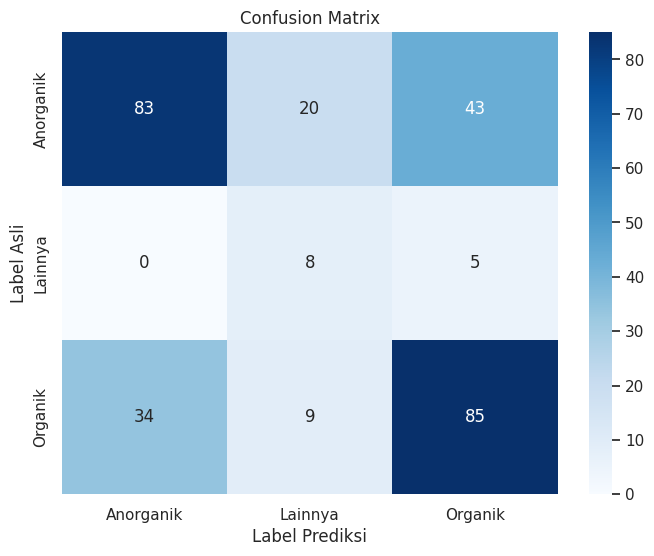

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(true_labels, predicted_labels), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Label Prediksi')
plt.ylabel('Label Asli')
plt.title('Confusion Matrix')
plt.show()

## Visualisasi Pelatihan Model


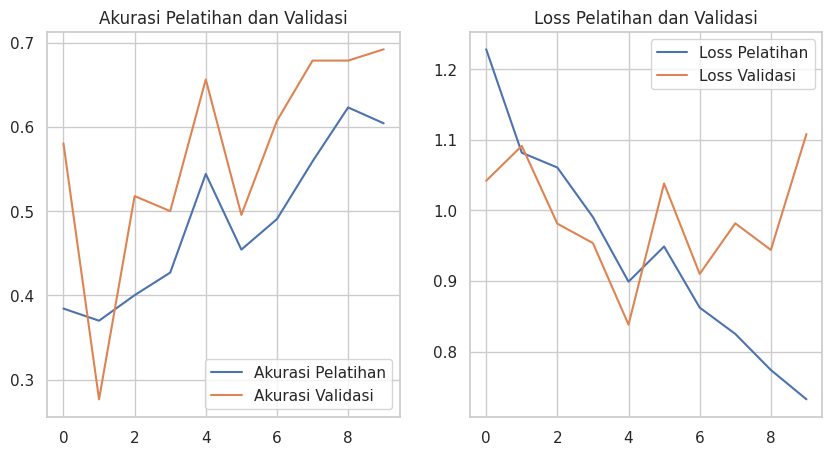

In [81]:
# Mengambil data riwayat pelatihan model
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Pelatihan')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi')
plt.title('Akurasi Pelatihan dan Validasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Pelatihan')
plt.plot(epochs_range, val_loss, label='Loss Validasi')
plt.title('Loss Pelatihan dan Validasi')
plt.legend()
plt.show()

## Prediksi Foto Baru

In [82]:
import cv2
from PIL import Image

# --- Helper Functions untuk Deteksi Kualitas Gambar ---

def is_blurry(image_path, blur_threshold=100.0):
    """Mendeteksi apakah gambar buram menggunakan Laplacian Variance."""
    try:
        img_cv = cv2.imread(image_path)
        if img_cv is None:
            print(f"[Kualitas Gambar] Peringatan: Tidak dapat memuat gambar dengan OpenCV: {image_path}")
            return False
        gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)
        fm = cv2.Laplacian(gray, cv2.CV_64F).var()
        return fm < blur_threshold
    except Exception as e:
        print(f"[Kualitas Gambar] Error saat mendeteksi keburaman '{image_path}': {e}")
        return False

def is_too_dark_or_bright(image_path, dark_threshold=40, bright_threshold=200):
    """Mendeteksi apakah gambar terlalu gelap atau terlalu terang menggunakan rata-rata piksel."""
    try:
        img_pil = Image.open(image_path).convert('L')
        mean_intensity = np.mean(np.array(img_pil))
        return mean_intensity < dark_threshold or mean_intensity > bright_threshold
    except Exception as e:
        print(f"[Kualitas Gambar] Error saat mendeteksi kecerahan '{image_path}': {e}")
        return False

def has_low_contrast(image_path, contrast_threshold=20.0):
    """Mendeteksi apakah gambar memiliki kontras rendah menggunakan standar deviasi piksel."""
    try:
        img_pil = Image.open(image_path).convert('L')
        std_dev = np.std(np.array(img_pil))
        return std_dev < contrast_threshold
    except Exception as e:
        print(f"[Kualitas Gambar] Error saat mendeteksi kontras '{image_path}': {e}")
        return False

print("Fungsi deteksi kualitas gambar (blur, brightness, contrast) telah siap.")

Fungsi deteksi kualitas gambar (blur, brightness, contrast) telah siap.


---

In [83]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os
from PIL import UnidentifiedImageError

CONFIDENCE_THRESHOLD_MAIN_CLASSES = 0.70

BLUR_THRESHOLD = 50.0 # Hanya gambar dengan variance Laplacian di bawah ini akan dianggap "terlalu buram"
DARK_THRESHOLD = 20   # Hanya gambar dengan mean intensity di bawah ini akan dianggap "terlalu gelap"
BRIGHT_THRESHOLD = 230 # Hanya gambar dengan mean intensity di atas ini akan dianggap "terlalu terang"
CONTRAST_THRESHOLD = 10.0 # Hanya gambar dengan standar deviasi piksel di bawah ini akan dianggap "kontras rendah"

def predict_new_image(image_path, model, class_names, img_size, normalization_layer, confidence_threshold=CONFIDENCE_THRESHOLD_MAIN_CLASSES):
    try:
        # 1. Periksa kualitas gambar terlebih dahulu
        # Cetak peringatan, tetapi tetap lanjutkan proses prediksi
        if is_blurry(image_path, BLUR_THRESHOLD):
            print(f"Gambar: {os.path.basename(image_path)} -> Peringatan: Gambar sedikit buram. Mungkin memengaruhi akurasi.")

        if is_too_dark_or_bright(image_path, DARK_THRESHOLD, BRIGHT_THRESHOLD):
            print(f"Gambar: {os.path.basename(image_path)} -> Peringatan: Gambar mungkin terlalu gelap atau terlalu terang. Mungkin memengaruhi akurasi.")

        if has_low_contrast(image_path, CONTRAST_THRESHOLD):
            print(f"Gambar: {os.path.basename(image_path)} -> Peringatan: Gambar memiliki kontras yang agak rendah. Mungkin memengaruhi akurasi.")

        # 2. Muat dan prproses gambar
        img = image.load_img(image_path, target_size=img_size)
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array_normalized = normalization_layer(img_array)

        # 3. Lakukan prediksi
        predictions = model.predict(img_array_normalized, verbose=0)
        probabilities = predictions[0]

        # 4. Prediksi kelas yang diprediksi dan kepercayaannya
        predicted_class_index = np.argmax(probabilities)
        max_confidence = np.max(probabilities)
        predicted_class_name = class_names[predicted_class_index]

        # 5. Logika ambang batas kepercayaan
        final_prediction_name = predicted_class_name

        # Jika prediksi adalah Anorganik atau Organik, tapi kepercayaannya rendah, ubah ke Lainnya
        if (predicted_class_name == 'Anorganik' or predicted_class_name == 'Organik') and max_confidence < confidence_threshold:
            final_prediction_name = 'Lainnya'

        # Tampilkan gambar
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"Gambar Input: {os.path.basename(image_path)}\nPrediksi Akhir: {final_prediction_name}")
        plt.axis("off")
        plt.show()

        print(f"Gambar: {os.path.basename(image_path)}")
        print(f"Probabilitas (Anorganik, Lainnya, Organik): {probabilities}")
        print(f"Prediksi Awal: {predicted_class_name} dengan kepercayaan {max_confidence:.2f}")
        print(f"Prediksi Akhir (dengan ambang batas): {final_prediction_name}")

        return final_prediction_name
    except FileNotFoundError:
        print(f"ERROR: File tidak ditemukan di '{image_path}'.")
        return "File tidak ditemukan"
    except UnidentifiedImageError:
        print(f"ERROR: '{image_path}' bukan file gambar yang valid atau format tidak didukung.")
        return "Format gambar tidak valid"
    except Exception as e:
        print(f"Terjadi kesalahan saat memproses '{image_path}': {e}")
        return "Terjadi kesalahan"

print("Fungsi `predict_new_image` telah diperbarui dengan deteksi kualitas gambar yang lebih permisif.")

Fungsi `predict_new_image` telah diperbarui dengan deteksi kualitas gambar yang lebih permisif.


###Beberapa Kategori


--- Prediksi 1 untuk pakaian.png ---


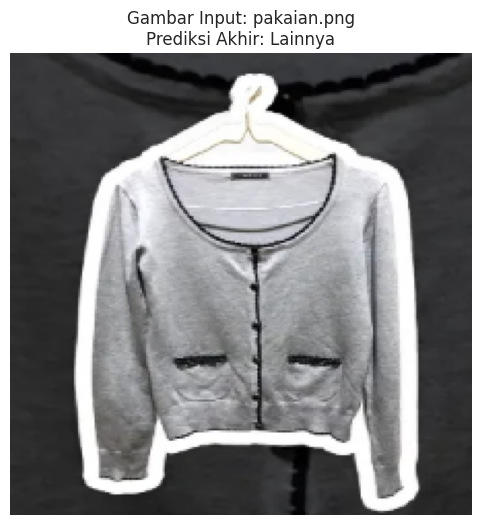

Gambar: pakaian.png
Probabilitas (Anorganik, Lainnya, Organik): [0.66178167 0.00191998 0.33629844]
Prediksi Awal: Anorganik dengan kepercayaan 0.66
Prediksi Akhir (dengan ambang batas): Lainnya
Kategori prediksi akhir untuk foto Anda adalah: Lainnya

--- Prediksi 2 untuk tulang ayam.png ---


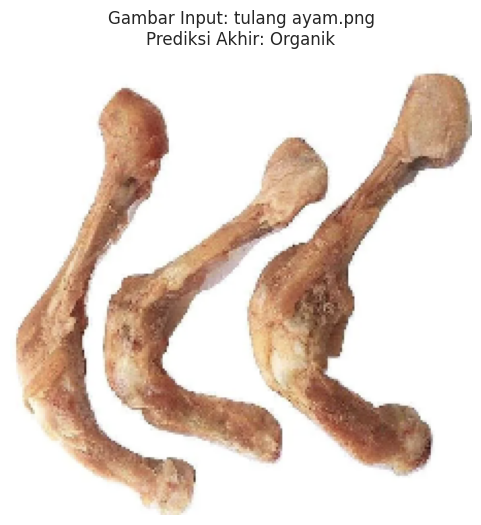

Gambar: tulang ayam.png
Probabilitas (Anorganik, Lainnya, Organik): [0.11670171 0.06114912 0.82214916]
Prediksi Awal: Organik dengan kepercayaan 0.82
Prediksi Akhir (dengan ambang batas): Organik
Kategori prediksi akhir untuk foto Anda adalah: Organik

ERROR: File foto tidak ditemukan di '/content/lalalala.png'. Pastikan Anda telah mengunggahnya dengan benar.

--- Prediksi 3 untuk psh.png ---
Gambar: psh.png -> Peringatan: Gambar sedikit buram. Mungkin memengaruhi akurasi.


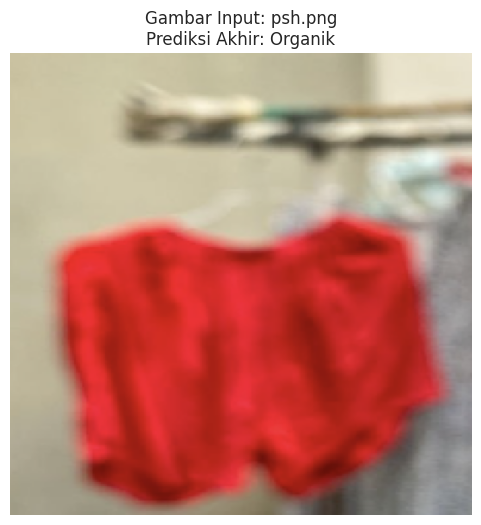

Gambar: psh.png
Probabilitas (Anorganik, Lainnya, Organik): [0.05311569 0.05771705 0.8891672 ]
Prediksi Awal: Organik dengan kepercayaan 0.89
Prediksi Akhir (dengan ambang batas): Organik
Kategori prediksi akhir untuk foto Anda adalah: Organik


In [84]:
# Prediksi 1 : Pakaian
new_image_path = '/content/pakaian.png'

if os.path.exists(new_image_path):
    print(f"\n--- Prediksi 1 untuk {os.path.basename(new_image_path)} ---")
    predicted_category = predict_new_image(new_image_path, model, class_names, IMAGE_SIZE, normalization_layer)
    print(f"Kategori prediksi akhir untuk foto Anda adalah: {predicted_category}")
else:
    print(f"\nERROR: File foto tidak ditemukan di '{new_image_path}'. Pastikan Anda telah mengunggahnya dengan benar.")

# Prediksi 2 : Tulang Ayam
sample_image_path_2 = "/content/tulang ayam.png"

if os.path.exists(sample_image_path_2):
    print(f"\n--- Prediksi 2 untuk {os.path.basename(sample_image_path_2)} ---")
    predicted_category = predict_new_image(sample_image_path_2, model, class_names, IMAGE_SIZE, normalization_layer)
    print(f"Kategori prediksi akhir untuk foto Anda adalah: {predicted_category}")
else:
    print(f"\nERROR: File foto tidak ditemukan di '{sample_image_path_2}'. Pastikan Anda telah mengunggahnya dengan benar.")

# Prediksi 3 : Tidak ada
sample_image_path_3 = "/content/lalalala.png"

if os.path.exists(sample_image_path_3):
    print(f"\n--- Prediksi 3 untuk {os.path.basename(sample_image_path_3)} ---")
    predicted_category = predict_new_image(sample_image_path_3, model, class_names, IMAGE_SIZE, normalization_layer)
    print(f"Kategori prediksi akhir untuk foto Anda adalah: {predicted_category}")
else:
    print(f"\nERROR: File foto tidak ditemukan di '{sample_image_path_3}'. Pastikan Anda telah mengunggahnya dengan benar.")

# Prediksi 4 : buram
sample_image_path_4 = "/content/psh.png"

if os.path.exists(sample_image_path_4):
    print(f"\n--- Prediksi 3 untuk {os.path.basename(sample_image_path_4)} ---")
    predicted_category = predict_new_image(sample_image_path_4, model, class_names, IMAGE_SIZE, normalization_layer)
    print(f"Kategori prediksi akhir untuk foto Anda adalah: {predicted_category}")
else:
    print(f"\nERROR: File foto tidak ditemukan di '{sample_image_path_4}'. Pastikan Anda telah mengunggahnya dengan benar.")

###Banyak Gambar Sekaligus


===== Memulai Prediksi Batch =====

--- Memproses Gambar 1/3: pakaian.png ---


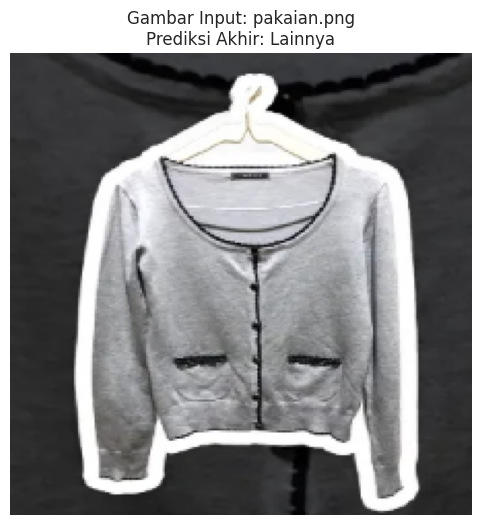

Gambar: pakaian.png
Probabilitas (Anorganik, Lainnya, Organik): [0.28537622 0.04514334 0.6694805 ]
Prediksi Awal: Organik dengan kepercayaan 0.67
Prediksi Akhir (dengan ambang batas): Lainnya

--- Memproses Gambar 2/3: tulang ayam.png ---


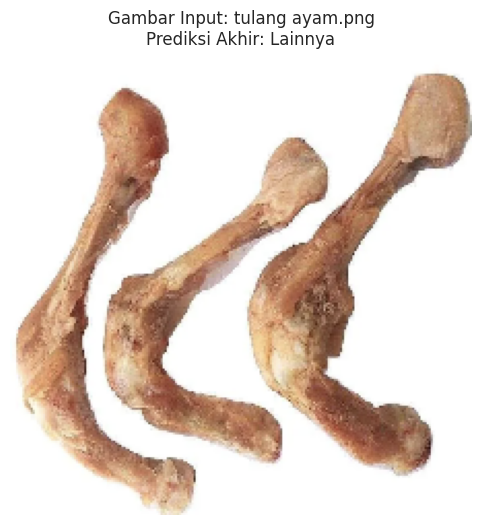

Gambar: tulang ayam.png
Probabilitas (Anorganik, Lainnya, Organik): [0.17484532 0.48528746 0.3398672 ]
Prediksi Awal: Lainnya dengan kepercayaan 0.49
Prediksi Akhir (dengan ambang batas): Lainnya

--- Memproses Gambar 3/3: california_housing_test.csv ---
[Kualitas Gambar] Peringatan: Tidak dapat memuat gambar dengan OpenCV: /content/sample_data/california_housing_test.csv
[Kualitas Gambar] Error saat mendeteksi kecerahan '/content/sample_data/california_housing_test.csv': cannot identify image file '/content/sample_data/california_housing_test.csv'
[Kualitas Gambar] Error saat mendeteksi kontras '/content/sample_data/california_housing_test.csv': cannot identify image file '/content/sample_data/california_housing_test.csv'
ERROR: '/content/sample_data/california_housing_test.csv' bukan file gambar yang valid atau format tidak didukung.

===== Prediksi Batch Selesai =====

Hasil Prediksi Keseluruhan:
pakaian.png: Lainnya
tulang ayam.png: Lainnya
california_housing_test.csv: Format gamba

In [65]:
def predict_multiple_images(image_paths, model, class_names, img_size, normalization_layer, confidence_threshold=CONFIDENCE_THRESHOLD_MAIN_CLASSES):
    results = {}
    for i, path in enumerate(image_paths):
        print(f"\n--- Memproses Gambar {i+1}/{len(image_paths)}: {os.path.basename(path)} ---")
        predicted_category = predict_new_image(path, model, class_names, img_size, normalization_layer, confidence_threshold)
        results[os.path.basename(path)] = predicted_category
    return results

# Contoh penggunaan:
# Kumpulkan semua path gambar yang ingin Anda uji
my_image_list = [
    '/content/pakaian.png',
    '/content/tulang ayam.png',
    '/content/sample_data/california_housing_test.csv' # Contoh file yang tidak valid
]

# Panggil fungsi untuk memprediksi banyak gambar
print("\n===== Memulai Prediksi Batch =====")
batch_predictions = predict_multiple_images(my_image_list, model, class_names, IMAGE_SIZE, normalization_layer)
print("\n===== Prediksi Batch Selesai =====")

print("\nHasil Prediksi Keseluruhan:")
for img_name, prediction in batch_predictions.items():
    print(f"{img_name}: {prediction}")

Dengan fungsi ini, AI dapat menguji gambar-gambar baru. Jika user ingin kategori 'Lainnya' mencakup hal-hal seperti pakaian atau makanan yang tidak ada dalam dataset pelatihan, model akan mencoba mengklasifikasikannya ke salah satu dari tiga kategori yang ada. Jika model tidak yakin untuk 'Anorganik' atau 'Organik', maka akan jatuh ke 'Lainnya'.

## Save Model


In [ ]:
model.save('waste_classifier_model.keras')

print("Model berhasil disimpan sebagai 'waste_classifier_model.keras'")

Model saved successfully to 'waste_classifier_model.keras'
